# Customer KPI & Segmentation EDA

This notebook is split from `02_customer_behavior.ipynb` for maintainability.


## Notebook Roadmap

1. Data Setup & KPI Baseline
2. Bivariate Behavior Comparison
3. Time-slot Pattern (Day x Hour)
4. Customer Segmentation (User-level)
5. Segment Preferences (Product / Aisle)
6. Retention & Churn
7. Basket Value by Category
8. CLV Trends & Segment CLV
9. Extra Diagnostics (Funnel / Gateway / Trend / Histogram)
10. Executive Summary

Run guide:
- ตั้งค่า `USE_SAMPLE` ที่ cell โหลดข้อมูล
- รันจากบนลงล่างเพื่อให้ตัวแปรกลาง (เช่น `rfm`, `segment_txn`, `customer_monthly`) พร้อมใช้งานครบ

In [11]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

def show_df(df, title=None, n=PREVIEW_ROWS):
    """Display full table only in verbose mode; otherwise show top-N preview."""
    if title:
        print(title)
    display(df if SHOW_VERBOSE_TABLES else df.head(n))

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Data mode: FULL DATASET
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,aisle_id,department_id,aisle,department,total_price,cumulative_reorder_per_customer
0,2539329,196,1,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Soda,77,7,soft drinks,beverages,1,0
1,2539329,14084,2,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Organic Unsweetened Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs,1,0
2,2539329,12427,3,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Original Beef Jerky,23,19,popcorn jerky,snacks,1,0
3,2539329,26088,4,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Aged White Cheddar Popcorn,23,19,popcorn jerky,snacks,1,0
4,2539329,26405,5,0,1,prior,1,2,8,0.0,0.0,2015-07-01,XL Pick-A-Size Paper Towel Rolls,54,17,paper goods,household,1,0


## 1) Customer Segmentation & Value Analysis

แบ่งลูกค้าออกเป็นกลุ่มตามพฤติกรรม แล้วประมาณ **มูลค่าสัมพัทธ์** ของแต่ละกลุ่มผ่าน Value Index

| ขั้นตอน | รายละเอียด |
|---------|-----------|
| 1.1 | สร้าง User Segment (Whales / Regulars / Churned) |
| 1.2 | กำหนด Value Weight ตาม Aisle → คำนวณ Value Index |
| 1.3 | Spending Intensity & Segment Strategy Map |

### 1.1) User Segmentaion

สร้างกลุ่มลูกค้าจาก **User-level features** เพื่อวิเคราะห์ "ความต่าง" ของพฤติกรรมให้ชัดขึ้น

Features หลัก:
- `total_orders` = จำนวนครั้งที่สั่งซื้อ
- `avg_basket_size` = จำนวนสินค้าเฉลี่ยต่อตะกร้า
- `reorder_ratio` = อัตราการซื้อซ้ำ
- `days_since_last_order` = วันตั้งแต่สั่งครั้งล่าสุด

Logic การแบ่ง Segment (แบบเรียบง่ายและตีความง่าย):
- **Whales**: ลูกค้าที่สั่งบ่อยมาก (`total_orders` อยู่ใน Top 10%)
- **Regulars**: ลูกค้าทั่วไป
- **Churned**: ลูกค้าที่ไม่ได้สั่งมานานเกิน 30 วัน

หมายเหตุ: ถ้าลูกค้าเข้าเงื่อนไข Churned จะถูกจัดเป็น `Churned` แม้จะเคยสั่งบ่อย (override เพื่อเน้นสถานะล่าสุด)

Segment summary:


,segment,users,median_total_orders,median_avg_basket_size,median_reorder_ratio,median_days_since_last_order
0,Whales,20644,51.0,9.315789,0.725983,1.0
1,Regulars,185565,8.0,8.863636,0.400000,1.0
2,Churned,0,NaN,NaN,NaN,NaN


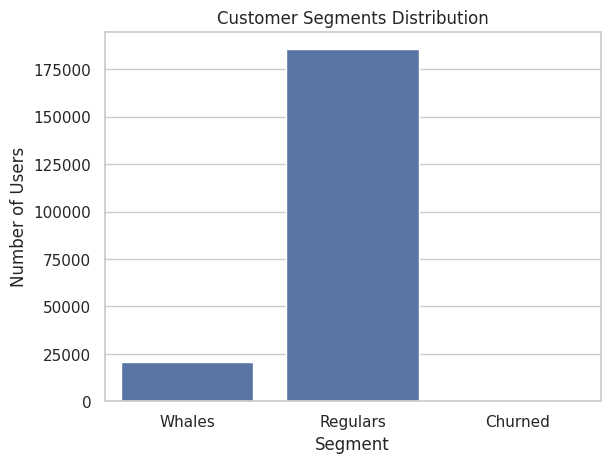

In [12]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

# 1) Order frequency + reorder behavior + recency per user
user_order_profile = (
    df.groupby("user_id", observed=False)
    .agg(
        total_orders=("order_id", "nunique"),
        reorder_ratio=("reordered", "mean"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

# 2) Basket size per order -> average basket size at user level
order_basket = (
    df.groupby(["user_id", "order_id"], observed=False)
    .agg(basket_size=("product_id", "count"))
    .reset_index()
)

user_basket_profile = (
    order_basket.groupby("user_id", observed=False)
    .agg(avg_basket_size=("basket_size", "mean"))
    .reset_index()
)

# Keep variable name `rfm` for downstream compatibility in this notebook.
rfm = user_order_profile.merge(user_basket_profile, on="user_id", how="left")
rfm["days_since_last_order"] = (snapshot_date - rfm["last_order_date"]).dt.days

# Segment rules
whale_threshold = rfm["total_orders"].quantile(0.90)
rfm["segment"] = "Regulars"
rfm.loc[rfm["total_orders"] >= whale_threshold, "segment"] = "Whales"
rfm.loc[rfm["days_since_last_order"] > 30, "segment"] = "Churned"

segment_order = ["Whales", "Regulars", "Churned"]
rfm["segment"] = pd.Categorical(rfm["segment"], categories=segment_order, ordered=True)

segment_summary = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_avg_basket_size=("avg_basket_size", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)

print("Segment summary:")
show_df(segment_summary)

sns.countplot(data=rfm, x="segment", order=segment_summary["segment"])
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Users")
plt.show()

### 💡 Segment Insights

#### 🐋 Whales — High-Value Power Users
> - ลูกค้ากลุ่มนี้มี **loyalty สูงมาก** (reorder ~73%)
> - สั่งซื้อบ่อย (51 orders median) และยัง active ล่าสุด
> - เป็นกลุ่มที่สร้างรายได้หลัก → **ควรรักษาไว้ด้วย loyalty program**

#### 👥 Regulars — Core Mainstream Users
> - เป็นฐานลูกค้าหลัก (~90%) แต่ **reorder ratio ยังต่ำ** (~40%)
> - พฤติกรรมอยู่ระหว่าง ทดลองสินค้าและซื้อซ้ำ
> - มี potential สูงในการ convert ไปเป็น Whales → **ใช้ personalized recommendation**

#### 🔴 Churned — Inactive Users
> - ไม่ได้สั่งซื้อมานานกว่า 30 วัน
> - ควรทำ **win-back campaign** ด้วย incentive หรือ reminder notification

---

### 1.2) Segment Value Contribution

เนื่องจากไม่มีข้อมูลราคาจริง เราจึงสร้าง **Value Index** จาก Aisle-level weight เพื่อประมาณมูลค่าสัมพัทธ์ของแต่ละ order line

**ขั้นตอน:**
1. สำรวจ Aisles ที่มีอยู่ในข้อมูล
2. กำหนด weight สำหรับแต่ละ aisle (ตามช่วงราคาตลาดทั่วไป)
3. คำนวณ `value_index = quantity × value_weight` ต่อ order line

In [13]:
aisles = (
    pd.Series(df["aisle"].dropna().unique(), name="aisle")
    .sort_values()
    .reset_index(drop=True)
)

aisle_counts = (
    df["aisle"]
    .value_counts(dropna=False)
    .rename_axis("aisle")
    .reset_index(name="order_lines")
)

print(f"Unique aisles: {len(aisles):,}")
show_df(aisle_counts, title="Aisle frequency (order lines):", n=len(aisle_counts))

Unique aisles: 134
Aisle frequency (order lines):


,aisle,order_lines
0,fresh fruits,3642188
1,fresh vegetables,3418021
2,packaged vegetables fruits,1765313
3,yogurt,1452343
4,packaged cheese,979763
5,milk,891015
6,water seltzer sparkling water,841533
7,chips pretzels,722470
8,soy lactosefree,638253
9,bread,584834


#### 📌 Value Weight Map

> **Assumption:** ไม่มีข้อมูลราคาจริง — ใช้ relative weight ตาม aisle category เพื่อประมาณ spending intensity
> Weight สูง = หมวดสินค้าราคาสูง (เช่น alcohol ≈ 3.0×, fresh produce ≈ 1.0×)

| กลุ่ม | ตัวอย่าง Aisle | Weight |
|------|--------------|--------|
| 🟢 Fresh / Low | fresh fruits, vegetables | 1.0× |
| 🟡 Dairy / Bakery | milk, yogurt, bread | 1.4–1.7× |
| 🔴 Meat / Seafood | meat counter, seafood | 2.3–2.7× |
| 🟣 Alcohol / Personal care | wines, spirits, skin care | 2.4–3.8× |

In [14]:
# Category-level value weight (relative, not actual price)
value_weight_map = {
    # 🟢 Fresh / Low value
    "fresh fruits": 1.0,
    "fresh vegetables": 1.0,
    "packaged vegetables fruits": 1.2,
    "fresh herbs": 1.3,
    "water seltzer sparkling water": 1.1,

    # 🟡 Dairy / Basic food
    "milk": 1.4,
    "yogurt": 1.5,
    "eggs": 1.5,
    "cream": 1.6,
    "butter": 1.6,
    "packaged cheese": 1.7,
    "other creams cheeses": 1.8,

    # 🟡 Bakery / carbs
    "bread": 1.4,
    "buns rolls": 1.4,
    "breakfast bakery": 1.5,
    "tortillas flat bread": 1.5,
    "dry pasta": 1.3,
    "grains rice dried goods": 1.3,

    # 🟡 Snacks / packaged
    "chips pretzels": 1.6,
    "crackers": 1.5,
    "cookies cakes": 1.7,
    "candy chocolate": 1.6,
    "popcorn jerky": 1.7,
    "trail mix snack mix": 1.8,
    "nuts seeds dried fruit": 1.8,

    # 🟡 Drinks
    "soft drinks": 1.4,
    "juice nectars": 1.5,
    "tea": 1.4,
    "coffee": 1.6,
    "energy sports drinks": 1.7,

    # 🔴 Protein / meat
    "meat counter": 2.5,
    "poultry counter": 2.4,
    "seafood counter": 2.7,
    "packaged meat": 2.3,
    "packaged poultry": 2.2,
    "packaged seafood": 2.4,
    "hot dogs bacon sausage": 2.2,
    "lunch meat": 2.0,

    # 🔴 Frozen / prepared
    "frozen meals": 2.0,
    "frozen produce": 1.6,
    "frozen pizza": 2.1,
    "frozen appetizers sides": 2.0,
    "frozen breakfast": 1.8,
    "prepared meals": 2.2,
    "prepared soups salads": 2.0,

    # 🔴 Pantry / cooking
    "canned meals beans": 1.6,
    "canned jarred vegetables": 1.4,
    "canned fruit applesauce": 1.4,
    "pasta sauce": 1.5,
    "condiments": 1.5,
    "spices seasonings": 1.6,
    "oils vinegars": 1.8,
    "baking ingredients": 1.5,
    "doughs gelatins bake mixes": 1.5,

    # 🔴 Special food
    "baby food formula": 2.5,
    "tofu meat alternatives": 2.2,
    "protein meal replacements": 2.6,
    "international": 1.7,
    "asian foods": 1.7,
    "latino foods": 1.6,
    "indian foods": 1.7,

    # 🟣 Premium / alcohol
    "beers coolers": 3.0,
    "red wines": 3.2,
    "white wines": 3.2,
    "spirits": 3.5,
    "specialty wines champagnes": 3.8,

    # 🟣 Non-food high value
    "cleaning products": 2.3,
    "laundry": 2.4,
    "dish detergents": 2.2,
    "paper goods": 2.0,
    "trash bags liners": 2.1,
    "air fresheners candles": 2.2,

    # 🟣 Personal care
    "personal care": 2.5,
    "oral hygiene": 2.3,
    "body lotions soap": 2.4,
    "hair care": 2.4,
    "skin care": 2.6,
    "facial care": 2.6,
    "deodorants": 2.2,
    "feminine care": 2.4,

    # 🟣 Baby / pets
    "diapers wipes": 2.8,
    "baby bath body care": 2.6,
    "baby accessories": 2.7,
    "cat food care": 2.4,
    "dog food care": 2.4,

    # fallback
    "missing": 1.5,
    "other": 1.5
}

# 2) CREATE VALUE INDEX
# =========================
df["value_weight"] = df["aisle"].map(value_weight_map)
df["value_weight"] = df["value_weight"].fillna(1.5)

df["quantity"] = 1
df["value_index"] = df["quantity"] * df["value_weight"]


In [15]:
# =========================
# 3) CUSTOMER LEVEL AGG
# =========================
customer_df = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_items=("product_id", "count"),
        total_value_index=("value_index", "sum"),
    )
    .reset_index()
)

customer_df["avg_value_per_order"] = (
    customer_df["total_value_index"] / customer_df["total_orders"]
)

customer_df["avg_items_per_order"] = (
    customer_df["total_items"] / customer_df["total_orders"]
)

# =========================
# 4) MERGE WITH RFM SEGMENT
# =========================
customer_df = customer_df.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left"
)

# =========================
# 5) SEGMENT KPI
# =========================
segment_kpi = (
    customer_df.groupby("segment")
    .agg(
        total_users=("user_id", "count"),
        total_value=("total_value_index", "sum"),
        avg_value_per_user=("total_value_index", "mean"),
        avg_orders=("total_orders", "mean"),
        avg_items_per_order=("avg_items_per_order", "mean"),
    )
    .reset_index()
)

# optional: sort by value
segment_kpi = segment_kpi.sort_values(
    by="total_value", ascending=False
)

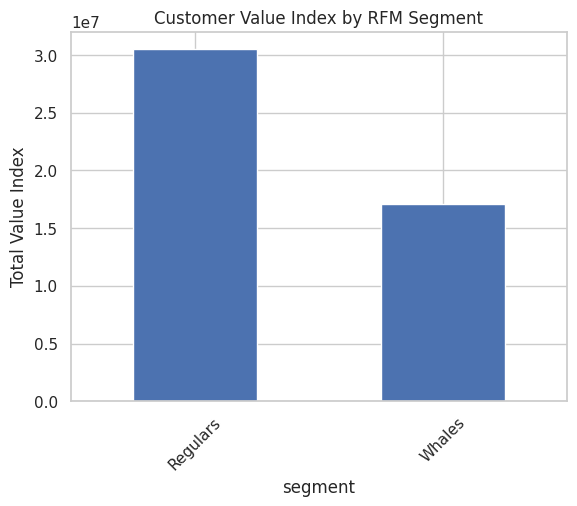

In [16]:
# =========================
# 6) VISUALIZATION
# =========================
plt.figure()
segment_kpi.set_index("segment")["total_value"].plot(kind="bar")
plt.title("Customer Value Index by RFM Segment")
plt.ylabel("Total Value Index")
plt.xticks(rotation=45)
plt.show()

---

### 1.3) Spending Intensity & Segment Strategy Map

วิเคราะห์ **ความเข้มข้นในการใช้จ่าย** ต่อลูกค้าในแต่ละ segment และสร้าง Strategy Map เพื่อเปรียบเทียบ:
- **Volume** (จำนวนลูกค้า) vs **Intensity** (มูลค่าเฉลี่ยต่อคน)
- ช่วยระบุ segment ที่มี ROI สูงสุดสำหรับ marketing investment

In [17]:
segment_kpi = (
    customer_df.groupby("segment")
    .agg(
        total_users=("user_id", "count"),
        total_value=("total_value_index", "sum"),
        avg_value_per_user=("total_value_index", "mean"),
        avg_orders=("total_orders", "mean"),
        avg_items_per_order=("avg_items_per_order", "mean"),
    )
    .reset_index()
)

segment_kpi["value_per_order"] = (
    segment_kpi["total_value"] / 
    (segment_kpi["avg_orders"] * segment_kpi["total_users"])
)

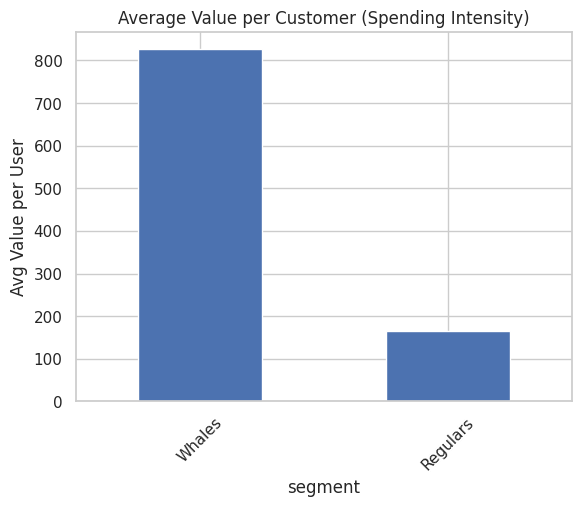

In [18]:
plt.figure()
segment_kpi.set_index("segment")["avg_value_per_user"].plot(kind="bar")
plt.title("Average Value per Customer (Spending Intensity)")
plt.ylabel("Avg Value per User")
plt.xticks(rotation=45)
plt.show()

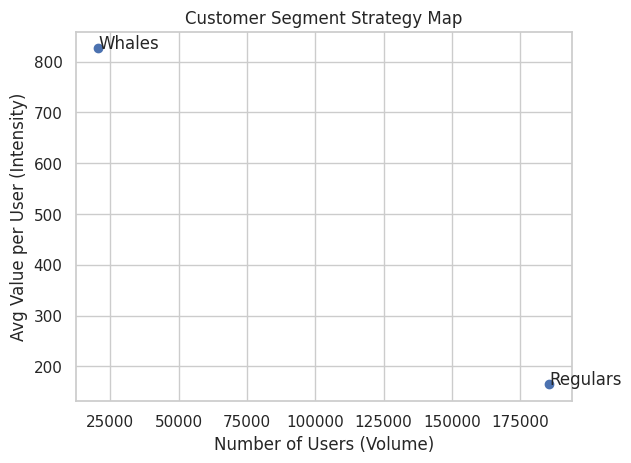

: 

In [ ]:
plt.figure()

plt.scatter(
    segment_kpi["total_users"],
    segment_kpi["avg_value_per_user"]
)

# label
for i, txt in enumerate(segment_kpi["segment"]):
    plt.annotate(
        txt,
        (segment_kpi["total_users"][i],
         segment_kpi["avg_value_per_user"][i])
    )

plt.xlabel("Number of Users (Volume)")
plt.ylabel("Avg Value per User (Intensity)")
plt.title("Customer Segment Strategy Map")

plt.show()